# Results

Reads `results/`, which `run.py` writes. No network, no price cache.

The strategy doesn't beat the S&P 500. The number worth having is the other one: how much the first
version of the backtest was flattering itself.

In [1]:
import json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd(), Path.cwd().parent) if (p / "qm_strategy.py").exists())
RES = ROOT / "results"

R = json.loads((RES / "backtest_results.json").read_text())
P = R["parameters"]

def curve(name):
    return pd.read_csv(RES / f"equity_curve_{name}.csv", parse_dates=["date"]).set_index("date")["value"]

EQ = {k: curve(k) for k in ("honest", "honest_trade_changes_only", "lookahead_fundamentals")}
SPY = pd.read_csv(RES / "spy_curve.csv", parse_dates=["date"]).set_index("date")["spy"]

print(f"{R['generated']} | {P['BACKTEST_START']} to {EQ['honest'].index[-1].date()} | "
      f"{R['backtests']['honest']['rebalances']} rebalances")
print(f"top {P['TOP_N']}, hysteresis {P['HYSTERESIS']}, {P['LOOKBACK_DAYS']}d lookback "
      f"skipping {P['SKIP_DAYS']}d, {P['TX_COST_BPS']} bps a side")

2026-09-09 16:00 | 2007-01-01 to 2026-09-09 | 237 rebalances
top 20, hysteresis 30, 252d lookback skipping 21d, 10 bps a side


## Metrics

Three runs of the same strategy, differing only in what the backtest was allowed to know at the time.

- `honest` — point-in-time membership, price-only screen, costs on real turnover
- `honest_trade_changes_only` — same, weights drift between rebalances instead of resetting to 1/N
- `lookahead_fundamentals` — same, but screens on today's ROE/EPS/market cap for all of history. Wrong;
  kept so the error can be priced.

In [2]:
rows = []
for key in ("honest", "honest_trade_changes_only", "lookahead_fundamentals"):
    b = R["backtests"][key]; s = b["strategy"]
    rows.append(dict(run=key, cagr=s["cagr"], excess=b["excess_cagr"], vol=s["vol"], sharpe=s["sharpe"],
                     max_dd=s["max_dd"], beat_spy=b["pct_months_beat_spy"],
                     turnover=b["turnover_per_rebalance"]))
spy = R["backtests"]["honest"]["spy"]
rows.append(dict(run="SPY", cagr=spy["cagr"], excess=0.0, vol=spy["vol"], sharpe=spy["sharpe"],
                 max_dd=spy["max_dd"], beat_spy=np.nan, turnover=np.nan))
T = pd.DataFrame(rows).set_index("run")
display(T.round(4))

gap = R["backtests"]["lookahead_fundamentals"]["excess_cagr"] - R["backtests"]["honest"]["excess_cagr"]
print(f"look-ahead fundamentals are worth {100*gap:.2f} pp of CAGR a year")
print(f"real excess {100*R['backtests']['honest']['excess_cagr']:.2f} pp")

,cagr,excess,vol,sharpe,max_dd,beat_spy,turnover
run,,,,,,,
honest,0.1153,0.0064,0.2696,0.4854,-0.6668,0.4788,0.4729
honest_trade_changes_only,0.1176,0.0087,0.2716,0.4912,-0.6698,0.4831,0.3966
lookahead_fundamentals,0.1401,0.0313,0.2628,0.5751,-0.6276,0.5339,0.3892
SPY,0.1089,0.0000,0.1960,0.5501,-0.5519,NaN,NaN


look-ahead fundamentals are worth 2.48 pp of CAGR a year
real excess 0.64 pp


## Equity curves

Log scale. Bottom panel is the ratio of the two strategy curves — the size of the look-ahead error
as it accumulates.

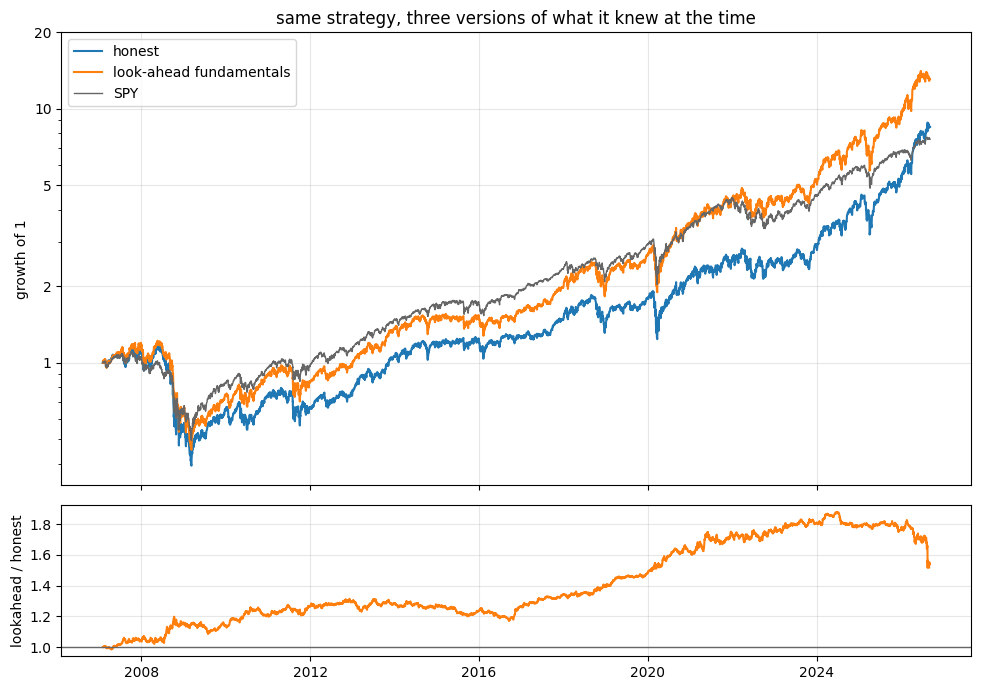

final: honest x8.49, look-ahead x13.07, SPY x7.58


In [3]:
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                              gridspec_kw=dict(height_ratios=[3, 1]))

ax.plot(EQ["honest"], label="honest")
ax.plot(EQ["lookahead_fundamentals"], label="look-ahead fundamentals")
ax.plot(SPY, label="SPY", color="0.4", lw=1)
ax.set_yscale("log"); ax.set_ylabel("growth of 1")
ax.set_yticks([1, 2, 5, 10, 20]); ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.legend(); ax.grid(alpha=0.3)
ax.set_title("same strategy, three versions of what it knew at the time")

ratio = EQ["lookahead_fundamentals"] / EQ["honest"]
ax2.plot(ratio, color="C1")
ax2.axhline(1.0, color="0.4", lw=1)
ax2.set_ylabel("lookahead / honest"); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"final: honest x{EQ['honest'].iloc[-1]:.2f}, "
      f"look-ahead x{EQ['lookahead_fundamentals'].iloc[-1]:.2f}, SPY x{SPY.iloc[-1]:.2f}")

## Drawdown

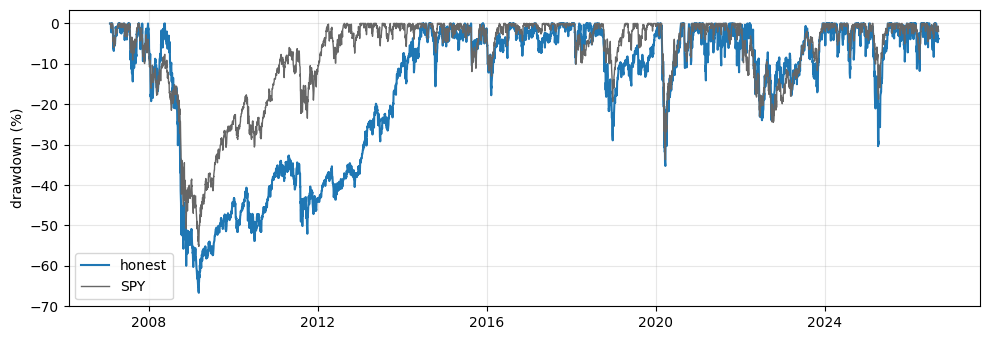

max drawdown: strategy -66.7%, SPY -55.2%, both 2009-03-09


In [4]:
dd = lambda s: 100 * (s / s.cummax() - 1)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(dd(EQ["honest"]), label="honest")
ax.plot(dd(SPY), label="SPY", color="0.4", lw=1)
ax.set_ylabel("drawdown (%)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

b = R["backtests"]["honest"]
print(f"max drawdown: strategy {100*b['strategy']['max_dd']:.1f}%, "
      f"SPY {100*b['spy']['max_dd']:.1f}%, both {b['strategy']['max_dd_date']}")

## Excess return by year

2007 and 2026 are part years — the backtest starts 31 Jan 2007 and the last run was in September.

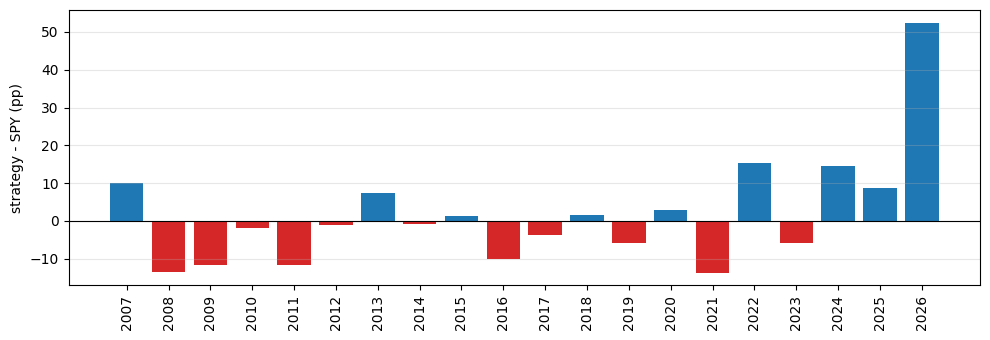

ahead in 9 of 20 years


year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
strategy,0.1351,-0.5023,0.1457,0.1328,-0.0988,0.1491,0.3972,0.1256,0.0253,0.0186,0.1810,-0.0303,0.2548,0.2127,0.1508,-0.0277,0.2022,0.3932,0.2646,0.6491
spy,0.0359,-0.3680,0.2635,0.1506,0.0190,0.1599,0.3231,0.1346,0.0123,0.1200,0.2171,-0.0457,0.3122,0.1833,0.2873,-0.1818,0.2618,0.2489,0.1772,0.1240


In [5]:
BY = pd.DataFrame(R["backtests"]["honest"]["by_year"]).set_index("year")
ex = 100 * (BY["strategy"] - BY["spy"])

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(ex.index, ex.values, color=["C0" if v >= 0 else "C3" for v in ex.values])
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("strategy - SPY (pp)"); ax.set_xticks(ex.index)
ax.tick_params(axis="x", labelrotation=90); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print(f"ahead in {int((ex > 0).sum())} of {len(ex)} years")
display(BY.round(4).T)

## Sub-periods

The first version of this backtest started in 2023, which is the last column.

,strategy_cagr,spy_cagr,strategy_sharpe,spy_sharpe,strategy_maxdd,spy_maxdd
period,,,,,,
2007-2012 (GFC + recovery),-0.0454,0.0201,-0.0117,0.1666,-0.6668,-0.5519
2013-2019,0.1257,0.1419,0.7103,1.0443,-0.2894,-0.1935
2020-2022 (covid + rate shock),0.1034,0.0730,0.4403,0.3762,-0.3528,-0.3372
2023-now (original backtest window),0.4139,0.2222,1.2754,1.1279,-0.3037,-0.1876


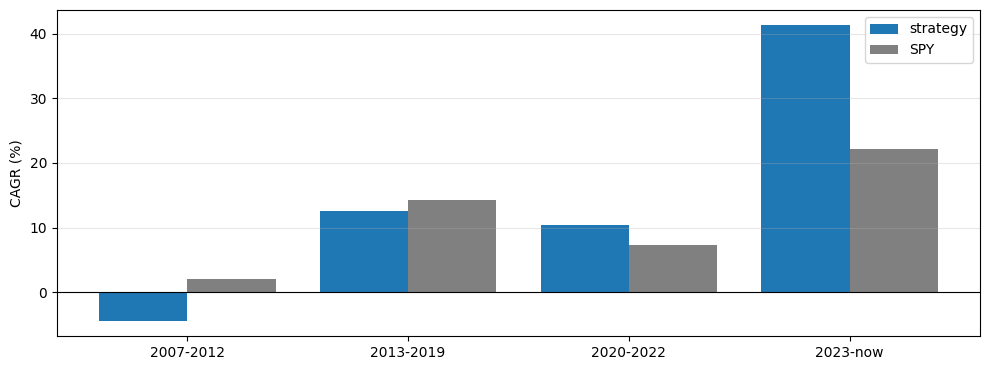

In [6]:
SP = pd.DataFrame(R["backtests"]["honest"]["sub_periods"]).set_index("period")
display(SP[["strategy_cagr", "spy_cagr", "strategy_sharpe", "spy_sharpe",
            "strategy_maxdd", "spy_maxdd"]].round(4))

x = np.arange(len(SP)); w = 0.4
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(x - w/2, 100*SP["strategy_cagr"], w, label="strategy")
ax.bar(x + w/2, 100*SP["spy_cagr"], w, label="SPY", color="0.5")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([p.split(" (")[0] for p in SP.index])
ax.set_ylabel("CAGR (%)"); ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## Data coverage

`members` is how many names were in the index that year, `with_prices` how many the free data source
still serves. The gap is companies acquired, delisted or renamed — in the index, absent from the
backtest. This is the survivorship bias that is left.

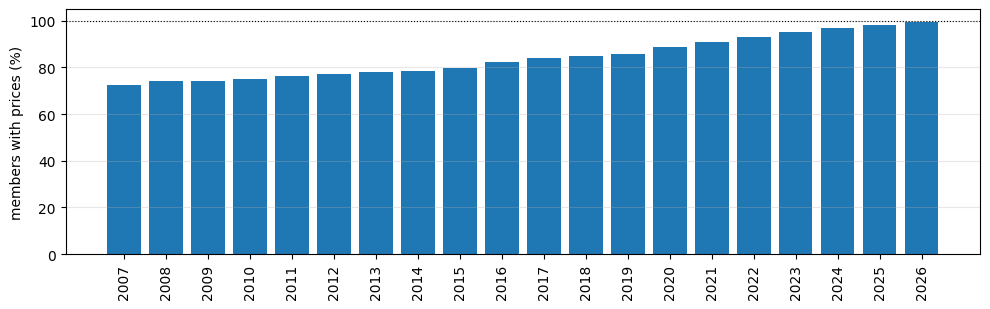

year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
members,497.0,497.0,499.0,498.0,497.0,497.0,497.0,498.0,501.0,505.0,506.0,505.0,505.0,505.0,505.0,504.0,503.0,503.0,503.0,503.0
with_prices,360.0,368.0,371.0,374.0,378.0,383.0,388.0,391.0,400.0,415.0,425.0,429.0,434.0,449.0,458.0,469.0,479.0,487.0,493.0,501.0
eligible,140.0,147.0,129.0,141.0,169.0,148.0,156.0,159.0,180.0,180.0,156.0,166.0,158.0,209.0,172.0,151.0,160.0,126.0,141.0,131.0
coverage,72.4,74.0,74.3,75.1,76.1,77.1,78.1,78.5,79.8,82.2,84.0,85.0,85.9,88.9,90.7,93.1,95.2,96.8,98.0,99.6


In [7]:
CV = pd.DataFrame(R["backtests"]["honest"]["coverage_by_year"]).set_index("year")
CV["coverage"] = (100 * CV["with_prices"] / CV["members"]).round(1)

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(CV.index, CV["coverage"])
ax.axhline(100, color="k", lw=0.8, ls=":")
ax.set_ylim(0, 105); ax.set_ylabel("members with prices (%)")
ax.set_xticks(CV.index); ax.tick_params(axis="x", labelrotation=90); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

display(CV.T)

## Current signal

The live screen does use fundamentals — they are known at trade time, which is why the backtest
above doesn't.

In [8]:
S = R["signal"]
print(f"as of {S['asof']} | {S['eligible']} passed the screen | "
      f"fundamentals {'used' if S['fundamentals_used'] else 'unavailable'}")
print("target:", " ".join(S["target"]))
print("sectors:", dict(sorted(S["sector_mix"].items(), key=lambda kv: -kv[1])))

sig = pd.read_csv(RES / f"signal_{S['asof']}.csv")
display(sig.head(20))

as of 2026-08-31 | 56 passed the screen | fundamentals used
target: CAT GOOGL TPR APH FSLR HPE FTNT CSCO STT HWM NTAP ADI MS DAL IBKR LUV TXN GS JCI PCAR
sectors: {'Information Technology': 8, 'Industrials': 6, 'Financials': 4, 'Communication Services': 1, 'Consumer Discretionary': 1}


,rank,ticker,status,mom_12_1_pct,beta_252d,avg_vol_M,roe_pct,mcap_B,sector,name
0,1.0,HPE,BUY,111.1,1.96,23.0,10.9,78.2,Information Technology,Hewlett Packard Enterprise Comp
1,2.0,FTNT,BUY,104.3,1.00,5.7,117.4,115.4,Information Technology,"Fortinet, Inc."
2,3.0,CAT,HOLD,89.0,1.75,3.2,57.0,374.9,Industrials,"Caterpillar, Inc."
3,4.0,CSCO,BUY,70.5,1.02,22.8,27.3,431.4,Information Technology,"Cisco Systems, Inc."
4,5.0,GOOGL,HOLD,68.8,1.37,31.7,48.7,4043.8,Communication Services,Alphabet Inc.
5,6.0,STT,BUY,63.9,1.06,2.1,12.4,52.7,Financials,State Street Corporation
6,7.0,HWM,BUY,60.5,1.10,2.7,34.7,92.8,Industrials,Howmet Aerospace Inc.
7,8.0,NTAP,BUY,54.9,1.29,2.7,114.8,36.3,Information Technology,"NetApp, Inc."
8,9.0,TPR,HOLD,50.4,1.16,2.9,197.1,22.7,Consumer Discretionary,"Tapestry, Inc."
9,10.0,ADI,BUY,46.4,1.65,4.5,12.2,176.9,Information Technology,"Analog Devices, Inc."
